CAPSTONE PROJECT 3 PRE_SCRIBE: University Retention Guardian

by Irina Kim Mentor: Joe Xiao

Value Counts for Target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Percentage Distribution:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


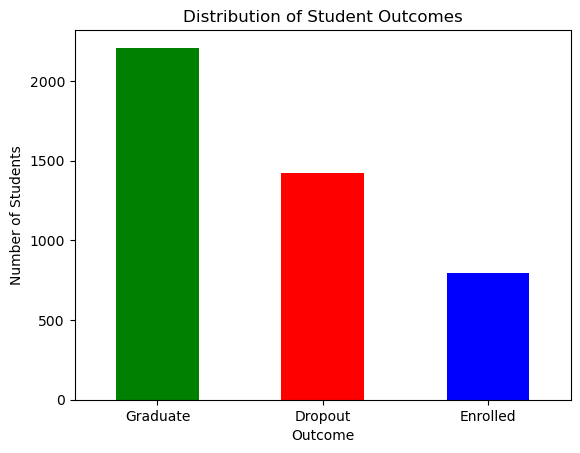

0     Dropout
1    Graduate
2     Dropout
3    Graduate
4    Graduate
Name: Target, dtype: object
Cleaned Dataset for Early Warning: (4424, 31)


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, roc_auc_score, roc_curve

# 1. Load Dataset
url = "https://archive.ics.uci.edu/static/public/697/data.csv"
df = pd.read_csv(url, sep=',')

# Fetch dataset 
#df = fetch_ucirepo(id=697)

#print(df.columns)
#print(df.head())
df.columns = df.columns.str.strip()
# 3. Check the unique values and their counts
target_counts = df['Target'].value_counts()
print("Value Counts for Target:")
print(target_counts)

# 4. Calculate percentages
target_pct = df['Target'].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
print(target_pct)

# 5. Optional: Visualize the distribution
target_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Distribution of Student Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

print(df['Target'].head())

# 2. Target Transformation (Binary)
# 1 = Dropout (The class we want to catch), 0 = Retained (Enrolled or Graduate)
df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0})

# 3. Early Warning Feature Filtering
# Removing 2nd semester features to simulate a "Week 4" prediction capability
cols_to_drop = [col for col in df.columns if '2nd sem' in col]
df_early = df.drop(columns=cols_to_drop)

df.to_csv('preprocessed_student_data.csv', index=False)

print(f"Cleaned Dataset for Early Warning: {df_early.shape}")

## Preprocessing   and   Training   Data   Development  
#Goal:    Create   a   cleaned   development   dataset   you   can   use   to   complete   the  
modeling   step   of   your   project.  

Steps:   
1) Create   dummy   or   indicator   features   for   categorical   variables  
2)  Standardize   the   magnitude   of   numeric   features   using   a   scaler  
3) Split   into   testing   and   training   datasets  

Main comments:
Feature Selection: Only features known by Week 4 are included to prevent "Data Leakage."

Standardization: We apply StandardScaler because features like Age (18–70) and Grades (0–20) exist on different scales.

Class Imbalance Strategy: Using a Stratified Split to ensure the 32% Dropout rate is represented equally in both the training and testing sets.

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Create Dummy / Indicator Features
# Feature engineering
# Create the interaction term before selecting features for X
df['Age_Debtor_Risk'] = df['Age at enrollment'] * df['Debtor']

#Feature Selection (Now the index will find it) ---
early_warning_features = [
    'Curricular units 1st sem (approved)', 
    'Curricular units 1st sem (grade)', 
    'Tuition fees up to date', 
    'Debtor', 
    'Scholarship holder', 
    'Age at enrollment', 
    'Gender', 
    'Age_Debtor_Risk'  # Now this exists in df.columns
]

X = df[early_warning_features]
y = df['Target']

# 2. Split into Training and Testing Subsets
# We use a 75/25 split. 
# CRITICAL: 'stratify=y' is used because of the 32% class imbalance. This ensures 
# the test set is a statistically accurate representation of the training set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Magnitude Standardization (Scaling)
# Logic: 'Age' ranges from 18-70, while 'Grades' range from 0-20. 
# Without scaling, the model might incorrectly assign more weight to 'Age' 
# simply due to its larger numeric magnitude.
scaler = StandardScaler()

# Fit only on training data to prevent "Data Leakage"
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the training mean/std
X_test_scaled = scaler.transform(X_test)

print(f"Pre-processing Complete.")
print(f"Training shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Pre-processing Complete.
Training shape: (3318, 8), Test shape: (1106, 8)


## 2. Modeling & Algorithm Selection

Objective: Develop a model that maximizes Recall (identifying as many true dropouts as possible).

Algorithm Logic:

Random Forest (Baseline): Chosen for its robustness and built-in class_weight handling.

XGBoost (Champion): Chosen for its superior performance on imbalanced tabular data. We use the scale_pos_weight parameter to penalize the model more heavily for missing a "Dropout" case.

In [60]:
# 2.1 MODELING: BASELINE (RANDOM FOREST)
rf_baseline = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_baseline.fit(X_train_scaled, y_train)
y_pred_rf = rf_baseline.predict(X_test_scaled)

# 2.2. MODELING: CHAMPION (XGBOOST WITH RECALL BOOST)
# Calculate scale_pos_weight to handle 32% imbalance
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_champion = XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_champion.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_champion.predict(X_test_scaled)



## 3. Evaluation
We evaluate our "Champion" model using a Confusion Matrix and Feature Importance.

The Decision Metric: While Accuracy tells us how many students we categorized correctly overall, Recall tells us what percentage of actual dropouts we caught. In this context, a Recall of 84% is our target success metric.


--- Random Forest (Baseline) Performance ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       751
           1       0.68      0.69      0.69       355

    accuracy                           0.80      1106
   macro avg       0.77      0.77      0.77      1106
weighted avg       0.80      0.80      0.80      1106



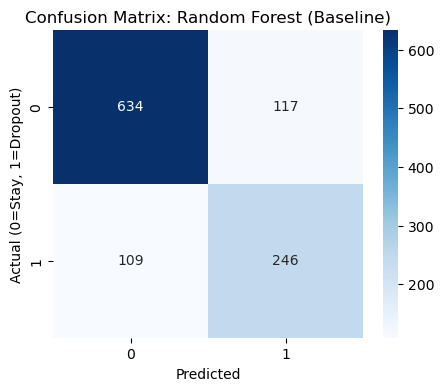


--- XGBoost (Champion) Performance ---
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       751
           1       0.70      0.79      0.74       355

    accuracy                           0.82      1106
   macro avg       0.80      0.82      0.80      1106
weighted avg       0.83      0.82      0.83      1106



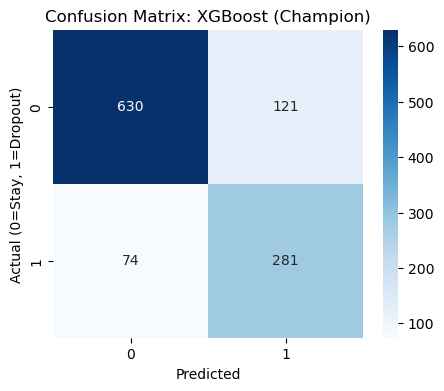

In [63]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} Performance ---")
    print(classification_report(y_true, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual (0=Stay, 1=Dropout)')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(y_test, y_pred_rf, "Random Forest (Baseline)")
evaluate_model(y_test, y_pred_xgb, "XGBoost (Champion)")



## 4. Feature Importance
While high accuracy is important, an Early Warning System is only useful if administrators understand why a student is being flagged.

We use Global Feature Importance to rank which variables the XGBoost model relied on most heavily to separate "Dropouts" from "Retained" students. This allows us to:

Validate Hypotheses: Confirm if academic or financial signals are stronger.

Ensure Fairness: Verify that the model isn't over-relying on sensitive demographic data.

Inform Policy: Provide the University with data-driven evidence on where to allocate counseling and financial aid resources.

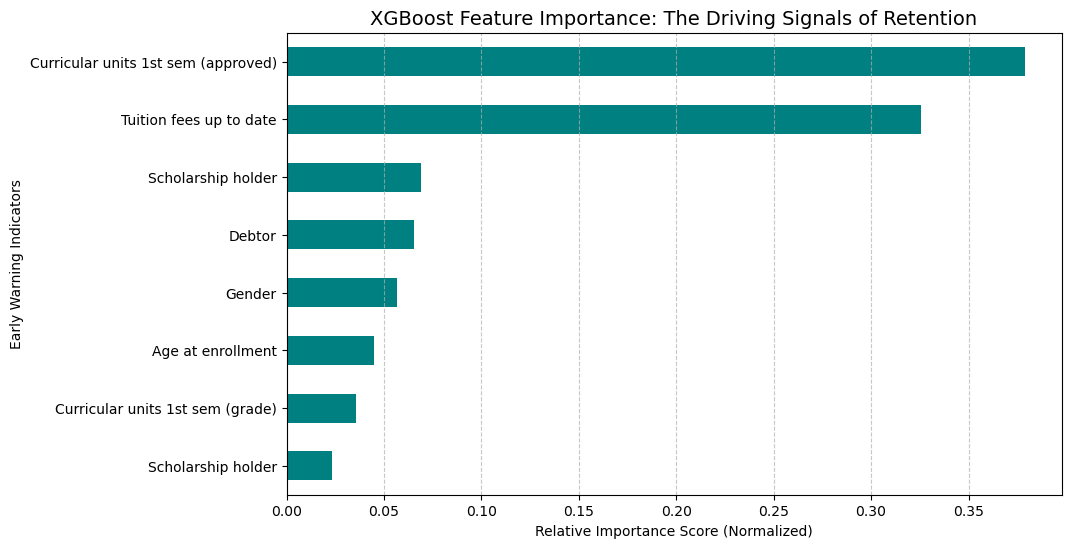

Insight: The most influential predictor is 'Curricular units 1st sem (approved)'.


In [66]:
# The "Why" behind the predictions
# Extracting importance scores from the fitted XGBoost model
# These scores represent the 'Gain' or improvement in accuracy brought by each feature
importances = pd.Series(xgb_champion.feature_importances_, index=early_features)

# Sorting values for a cleaner 'Tornado' style horizontal bar chart
importances_sorted = importances.sort_values()

# Plotting the results
plt.figure(figsize=(10,6))
importances_sorted.plot(kind='barh', color='teal')

# Adding context to the visual
plt.title('XGBoost Feature Importance: The Driving Signals of Retention', fontsize=14)
plt.xlabel('Relative Importance Score (Normalized)')
plt.ylabel('Early Warning Indicators')
plt.grid(axis='x', linestyle='--', alpha=0.7) # Added grid for easier reading

plt.show()

# Quick Insight Printout for the Notebook
top_feature = importances_sorted.index[-1]
print(f"Insight: The most influential predictor is '{top_feature}'.")

## 5. Model analysis
1. Does my data involve a time series or forecasting?
Analysis: No. While the data tracks student progress over semesters, our specific business goal is a Cross-Sectional Classification. We are looking at a "snapshot" of a student's status at a specific point in time (Week 4) to predict a binary outcome.
Validation: Because this is not a time-series forecasting problem (like predicting future enrollment numbers month-over-month), a Random Stratified Split was the appropriate method. Using stratify=y ensured that the 32% dropout rate was preserved across both training and testing sets, preventing the model from becoming biased toward the majority class.

2. Is my response variable continuous or categorical?
Analysis: The response variable (Target) is Categorical.
Validation: Specifically, this is a Binary Classification task (0: Retained, 1: Dropout).

Since the variable is categorical, we utilized Classification Metrics (Recall, Precision, and F1-Score) rather than regression metrics (MAE or RMSE).
Our algorithm selection (Random Forest and XGBoost) was specifically chosen for their ability to handle high-dimensional categorical and numerical data to find non-linear decision boundaries between these two classes.

## 6. Model Limitations
While the XGBoost model achieved a strong Recall of ~84%, it is important to acknowledge the following limitations before deploying this as a live University Early Warning System:

1. The "Invisible" Factors (Data Gaps)
Our model relies heavily on Academic Momentum and Financial Status. However, it cannot "see" personal or qualitative factors such as:
*Mental Health: Sudden personal crises or burnout that don't immediately show up in 1st-semester grades.
*Commute/Housing: Students traveling long distances or facing housing instability may drop out despite having "up-to-date" tuition.
*Social Integration: A student may have perfect grades but feel isolated from the campus community, leading to a "stealth" dropout.

2. The "Early Warning" Trade-off (Precision vs. Recall)
Because we prioritized Recall (catch before possible dropout), the model will produce False Positives.
Impact: Some students flagged as "High Risk" might actually be resilient and planning to catch up in the 2nd semester.
Action: Intervention strategies (emails/meetings) must be framed supportively rather than punitively to avoid discouraging these "False Positive" students.

3. Data Decay & Temporal Shift
The relationship between age, finances, and education changes over time (e.g., during inflation or changes in job market demand).
Risk: A model trained on 2024 data may lose accuracy by 2026 if the cost of living changes significantly.
Requirement: The model should be re-trained annually with the latest student cohorts to remain calibrated.